In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import matplotlib.gridspec as gridspec
from pathlib import Path
import joblib

In [2]:
SAGD_dist_matrix_list=[]
path = Path(f'../data/exp_6')
for d in [2, 50, 256, 1024, 16384]:
    loaded_data = joblib.load(path / f"D{d}_N1000_T10/history.jbl")
    CTDs= joblib.load(path / f"D{d}_N1000_T10/CTDs.jbl")
    T = loaded_data['params']['T']
    n_steps = loaded_data['params']['n_steps']
    dt = T / n_steps
    time_snaps = loaded_data['params']['times_snapshots']
    t_s = loaded_data['params']["ts_theoretical"]
    ts_idx = np.argmin(np.abs(time_snaps - t_s))
    SAGD_dist_matrix = joblib.load(path / f"D{d}_N1000_T10/SAGD.jbl")
    SAGD_dist_matrix_list.append((SAGD_dist_matrix, time_snaps,  t_s, ts_idx))
    

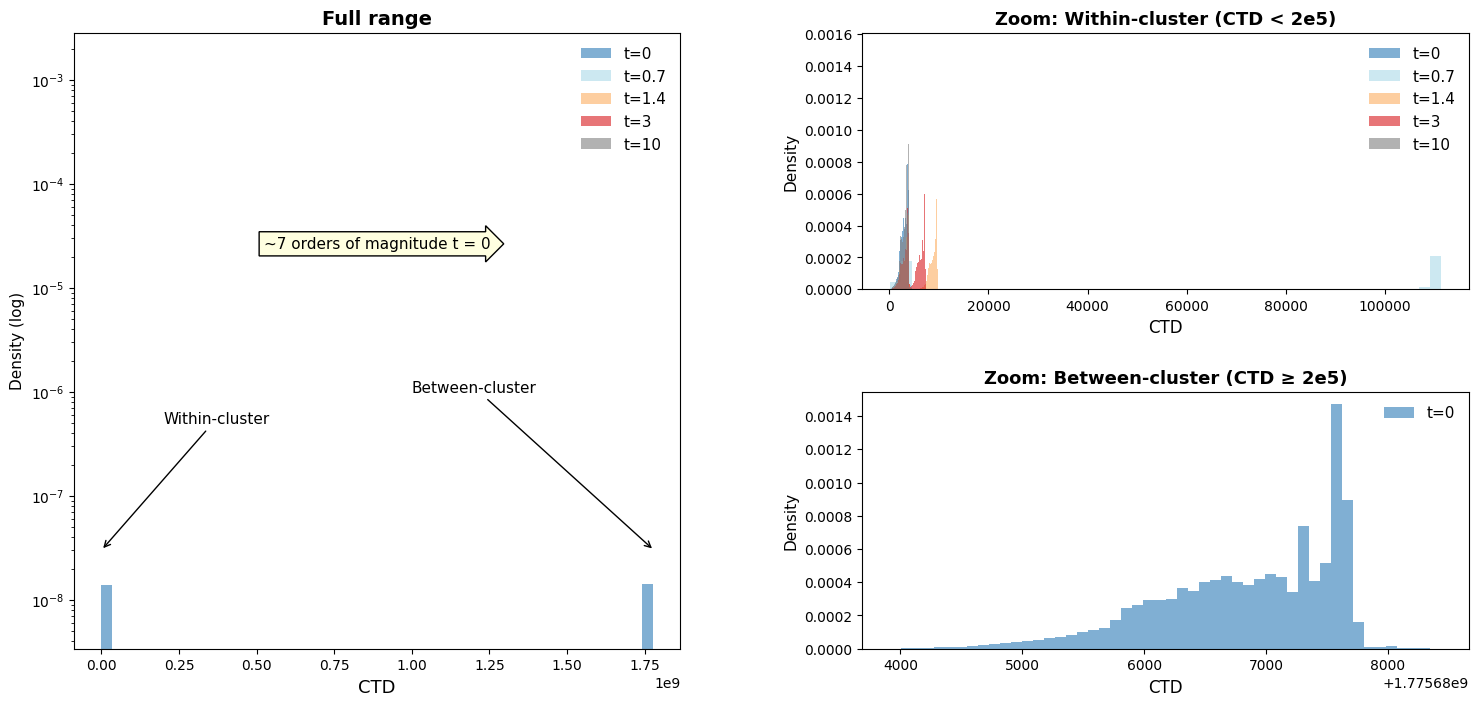

In [5]:
t_values = [0.0, 0.7000000000000001, 1.4000000000000001, 3.0, 10.0]
labels = ['t=0', 't=0.7', 't=1.4', 't=3', 't=10']
colors = ['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c', '#808080']

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax_full = fig.add_subplot(gs[:, 0])   
ax_intra = fig.add_subplot(gs[0, 1])   
ax_inter = fig.add_subplot(gs[1, 1])   

for t, label, color in zip(t_values, labels, colors):
    ctds = np.array(CTDs['CTDs'][t]['ctds'])

    ax_full.hist(ctds, bins=50, density=True, alpha=0.6, color=color, label=label, log=True)

    intra = ctds[ctds < 2e5]
    ax_intra.hist(intra, bins=50, density=True, alpha=0.6, color=color, label=label)

    inter = ctds[ctds >= 2e5]
    if len(inter) > 0:
        ax_inter.hist(inter, bins=50, density=True, alpha=0.6, color=color, label=label)

zoom_x = 2e5
y_min, y_max = ax_full.get_ylim()

ax_full.set_title('Full range', fontweight='bold', fontsize=14)
ax_full.set_xlabel('CTD', fontsize=13)
ax_full.set_ylabel('Density (log)', fontsize=11)
ax_full.legend(fontsize=11, frameon=False)
ax_full.annotate('Between-cluster', xy=(1.78e9, 3e-8), xytext=(1.0e9, 1e-6), fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))
ax_full.annotate('Within-cluster', xy=(5e3, 3e-8), xytext=(2e8, 5e-7), fontsize=11, arrowprops=dict(arrowstyle='->', color='black'))
ax_full.text(0.5, 0.65, '~7 orders of magnitude t = 0',
             transform=ax_full.transAxes, fontsize=11, ha='center',
             bbox=dict(boxstyle='rarrow,pad=0.3', facecolor='lightyellow'))

ax_intra.set_title('Zoom: Within-cluster (CTD < 2e5)',
                   fontweight='bold', fontsize=13)
ax_intra.set_xlabel('CTD', fontsize=12)
ax_intra.set_ylabel('Density', fontsize=11)
ax_intra.legend(fontsize=11, frameon=False)

ax_inter.set_title('Zoom: Between-cluster (CTD ≥ 2e5)',
                   fontweight='bold', fontsize=13)
ax_inter.set_xlabel('CTD', fontsize=12)
ax_inter.set_ylabel('Density', fontsize=11)
ax_inter.legend(fontsize=11, frameon=False, loc='upper right')

plt.savefig('raw_ctd_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

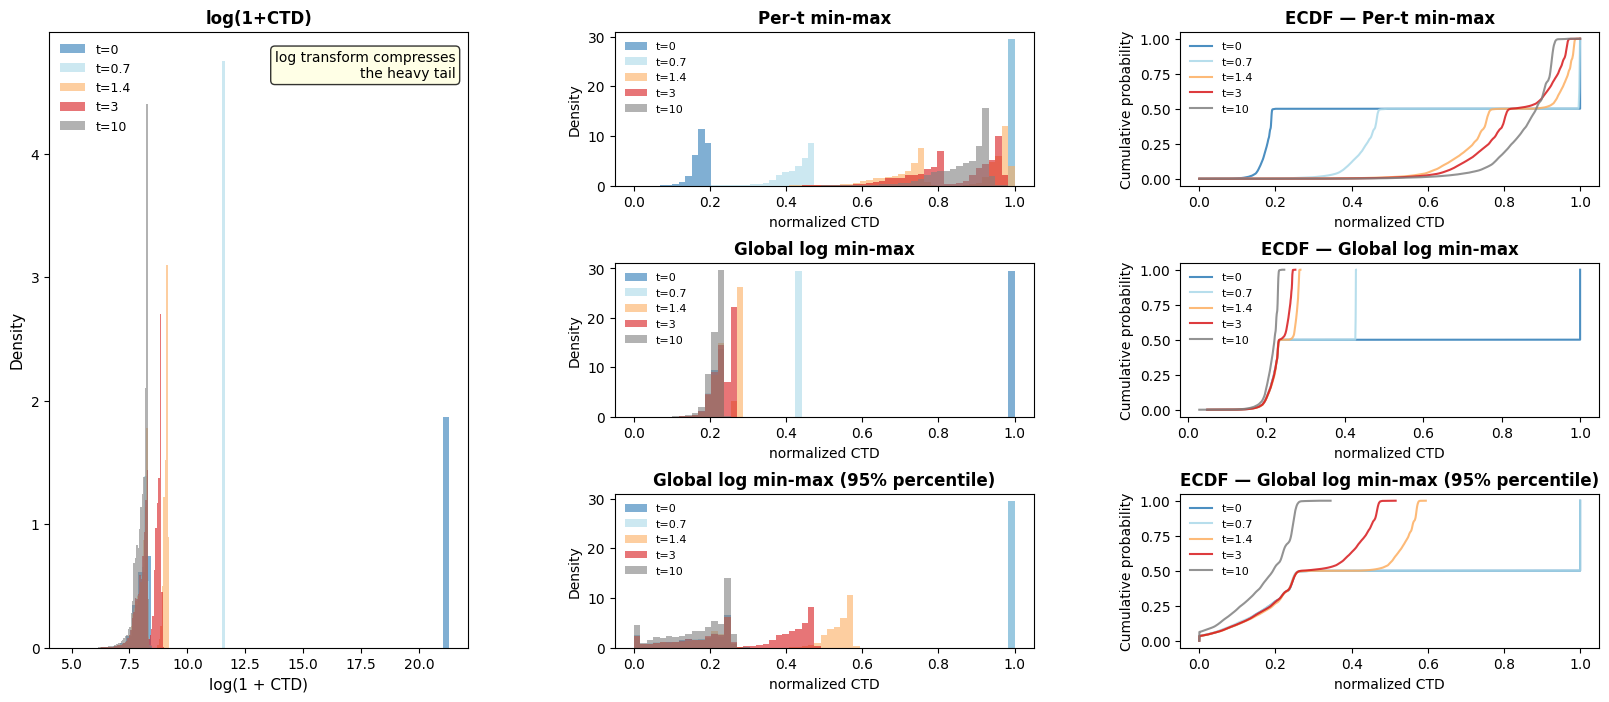

In [25]:
all_log_ctds = np.concatenate([np.log1p(np.array(CTDs['CTDs'][t]['ctds'])) for t in CTDs['CTDs'].keys()])
g_min_no_clip = all_log_ctds.min()
g_max_no_clip = all_log_ctds.max()
g_min_clip = np.percentile(all_log_ctds, 5)
g_max_clip = np.percentile(all_log_ctds, 95)
shared_bins = np.linspace(0, 1, 60)

fig = plt.figure(figsize=(20, 8))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# col 0: log CTD full height
ax_log = fig.add_subplot(gs[:, 0])

# col 1: histograms
ax_hist_pert  = fig.add_subplot(gs[0, 1])
ax_hist_global = fig.add_subplot(gs[1, 1])
ax_hist_clip = fig.add_subplot(gs[2, 1])

# col 2: ECDFs
ax_ecdf_pert = fig.add_subplot(gs[0, 2])
ax_ecdf_global = fig.add_subplot(gs[1, 2])
ax_ecdf_clip = fig.add_subplot(gs[2, 2])

for t, label, color in zip(t_values, labels, colors):
    ctds     = np.array(CTDs['CTDs'][t]['ctds'])
    log_ctds = np.log1p(ctds)
    per_t = (log_ctds - log_ctds.min()) / (log_ctds.max() - log_ctds.min())
    global_no_clip = (log_ctds - g_min_no_clip) / (g_max_no_clip - g_min_no_clip)
    global_clip = (np.clip(log_ctds, g_min_clip, g_max_clip) - g_min_clip) / (g_max_clip - g_min_clip)

    # col 0
    ax_log.hist(log_ctds, bins=60, density=True, alpha=0.6, color=color, label=label)

    # col 1: histograms
    ax_hist_pert.hist(per_t, bins=shared_bins, density=True, alpha=0.6, color=color, label=label)
    ax_hist_global.hist(global_no_clip, bins=shared_bins, density=True, alpha=0.6, color=color, label=label)
    ax_hist_clip.hist(global_clip, bins=shared_bins, density=True, alpha=0.6, color=color, label=label)
    # col 2: ECDFs
    for ax, arr in [(ax_ecdf_pert,   per_t), (ax_ecdf_global, global_no_clip), (ax_ecdf_clip,   global_clip)]:
        sorted_arr = np.sort(arr)
        ecdf = np.arange(1, len(sorted_arr) + 1) / len(sorted_arr)
        ax.plot(sorted_arr, ecdf, color=color, linewidth=1.5,label=label, alpha=0.85)

# ── col 0 ─────────────────────────────────────────────────────────────────────
ax_log.set_title('log(1+CTD)', fontweight='bold', fontsize=12)
ax_log.set_xlabel('log(1 + CTD)', fontsize=11)
ax_log.set_ylabel('Density', fontsize=11)
ax_log.legend(fontsize=9, frameon=False)
ax_log.text(0.97, 0.97, 'log transform compresses\nthe heavy tail',
            transform=ax_log.transAxes, fontsize=10, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── col 1 titles ──────────────────────────────────────────────────────────────
ax_hist_pert.set_title('Per-t min-max', fontweight='bold', fontsize=12)
ax_hist_pert.set_xlabel('normalized CTD', fontsize=10)
ax_hist_pert.set_ylabel('Density', fontsize=10)
ax_hist_pert.legend(fontsize=8, frameon=False, loc='upper left')

ax_hist_global.set_title('Global log min-max',
                          fontweight='bold', fontsize=12)
ax_hist_global.set_xlabel('normalized CTD', fontsize=10)
ax_hist_global.set_ylabel('Density', fontsize=10)
ax_hist_global.legend(fontsize=8, frameon=False, loc='upper left')

ax_hist_clip.set_title('Global log min-max (95% percentile)',
                        fontweight='bold', fontsize=12)
ax_hist_clip.set_xlabel('normalized CTD', fontsize=10)
ax_hist_clip.set_ylabel('Density', fontsize=10)
ax_hist_clip.legend(fontsize=8, frameon=False, loc='upper left')

# ── col 2 titles ──────────────────────────────────────────────────────────────
ax_ecdf_pert.set_title('ECDF — Per-t min-max', fontweight='bold', fontsize=12)
ax_ecdf_pert.set_xlabel('normalized CTD', fontsize=10)
ax_ecdf_pert.set_ylabel('Cumulative probability', fontsize=10)
ax_ecdf_pert.legend(fontsize=8, frameon=False, loc='upper left')

ax_ecdf_global.set_title('ECDF — Global log min-max',
                          fontweight='bold', fontsize=12)
ax_ecdf_global.set_xlabel('normalized CTD', fontsize=10)
ax_ecdf_global.set_ylabel('Cumulative probability', fontsize=10)
ax_ecdf_global.legend(fontsize=8, frameon=False, loc='upper left')

ax_ecdf_clip.set_title('ECDF — Global log min-max (95% percentile)',
                        fontweight='bold', fontsize=12)
ax_ecdf_clip.set_xlabel('normalized CTD', fontsize=10)
ax_ecdf_clip.set_ylabel('CDF', fontsize=10)
ax_ecdf_clip.legend(fontsize=8, frameon=False, loc='upper left')

plt.savefig('figs/ctd_ecdf_full.png', dpi=150, bbox_inches='tight')
plt.show()